# Week 10 — Baseline Decision Tree Experiments

Project: **Credit Card Fraud Detection**

Notebook location: `notebooks/week10/10_decision_tree_experiments.ipynb`  
Working directory (σε σχέση με το root): χρησιμοποιούμε `../../` για να πηγαίνουμε στο
`cc-fraud-detection/`.

Σε αυτό το notebook:

1. Φορτώνουμε το **τελικό dataset μοντελοποίησης** από το Week 8:  
   `data/data_interim/creditcard_features_week8.csv`
2. Δημιουργούμε **stratified train/val/test splits (60% / 20% / 20%)** και τα αποθηκεύουμε:
   - `data/data_interim/train.csv`
   - `data/data_interim/val.csv`
   - `data/data_interim/test.csv`
3. Εκπαιδεύουμε ένα **baseline Decision Tree Classifier**.
4. Υπολογίζουμε metrics στο **test set** και τα αποθηκεύουμε σε JSON.
5. Παράγουμε:
   - ROC curve
   - Precision–Recall curve
   - Confusion Matrix (εικόνα)

Το notebook λειτουργεί σαν experimental sandbox.  
Το production script θα είναι: `src/10_decision_tree.py`.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
)

# Όλα τα paths είναι σχετικά με το notebook: notebooks/week10/ -> ../../ -> project root
PROJECT_ROOT = Path("../../").resolve()
print("PROJECT_ROOT:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data" / "data_interim"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "week10"
RAW_DIR = PROJECT_ROOT / "reports" / "week10_decision_tree_vs_logreg"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR, FIG_DIR, RAW_DIR


PROJECT_ROOT: C:\Users\ΛΑΖΑΡΟΣ\Documents\Projects\cc-fraud-detection


(WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/data/data_interim'),
 WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/figures/week10'),
 WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/week10_decision_tree_vs_logreg'))

## 1. Modeling dataset από Week 8

Χρησιμοποιούμε ως βάση το dataset:

- `data/data_interim/creditcard_features_week8.csv`

Στο αρχείο αυτό έχουν ήδη γίνει:

- scaling στο **Amount**
- τυχόν feature engineering από την Εβδομάδα 8
- διατήρηση της στήλης **`Class`** σαν target.


In [2]:
features_path = DATA_DIR / "creditcard_features_week8.csv"
features_path


WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/data/data_interim/creditcard_features_week8.csv')

In [3]:
df_model = pd.read_csv(features_path)
df_model.shape


(284807, 35)

### 1.1. Κατανομή κλάσεων στο πλήρες dataset

Υπενθύμιση της ανισορροπίας κλάσεων πριν κάνουμε splits.


In [4]:
df_model["Class"].value_counts(normalize=True).rename("proportion")


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

## 2. Δημιουργία train / val / test splits (60% / 20% / 20%)

Δεν είχαν δημιουργηθεί από προηγούμενες εβδομάδες τα:

- `train.csv`
- `val.csv`
- `test.csv`

Οπότε εδώ:

1. Κάνουμε 1ο split: **train_val (80%)** / **test (20%)**, stratified ως προς `Class`.
2. Κάνουμε 2ο split: από το train_val, φτιάχνουμε:
   - train (60% συνολικά)
   - val (20% συνολικά)
3. Αποθηκεύουμε τα τρία αρχεία στο `data/data_interim/`.

Τα splits είναι **stratified**, ώστε η αναλογία fraud/non-fraud να μένει σταθερή.


In [5]:
TARGET_COL = "Class"

# 1ο split: train_val / test
train_val, test = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model[TARGET_COL], # επειδή η απάτη είναι σπάνια (~0.17%), η στρωματοποίηση διατηρεί ίδια αναλογία fraud/non-fraud σε κάθε split. Χωρίς αυτό, το test μπορεί να τύχει “φτωχό” σε fraud και να πάρεις παραπλανητικές μετρικές
    random_state=42,
) # Business νόημα: το test set προσομοιώνει “άγνωστα” μελλοντικά δεδομένα. Ποτέ δεν το ακουμπάς για επιλογές threshold, hyperparameters, SMOTE κ.λπ. Μόνο στο τέλος για τίμια αξιολόγηση

# 2ο split: train / val από το train_val
train, val = train_test_split(
    train_val,
    test_size=0.25,              # εδώ σημαίνει 25% του 80% ⇒ 0.8 × 0.25 = 0.20. Άρα τελικά: Train 60% — Val 20% — Test 20%
    stratify=train_val[TARGET_COL],
    random_state=42,
) # Business νόημα: χρησιμοποιείς το validation για όλες τις αποφάσεις πολιτικής (thresholds, κόστος, hyperparameters). To test μένει “κλειστό” έως το τέλος, οπότε η τελική αναφορά σου είναι αξιόπιστη

train_path = DATA_DIR / "train.csv"
val_path = DATA_DIR / "val.csv"
test_path = DATA_DIR / "test.csv"

train.to_csv(train_path, index=False)
val.to_csv(val_path, index=False)
test.to_csv(test_path, index=False)

train_path, val_path, test_path


(WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/data/data_interim/train.csv'),
 WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/data/data_interim/val.csv'),
 WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/data/data_interim/test.csv'))

In [6]:
train.shape, val.shape, test.shape


((170883, 35), (56962, 35), (56962, 35))

### 2.1. Έλεγχος κατανομής Class σε train / val / test


In [7]:
print("Train class distribution:")
display(train[TARGET_COL].value_counts(normalize=True).rename("proportion"))

print("\nVal class distribution:")
display(val[TARGET_COL].value_counts(normalize=True).rename("proportion"))

print("\nTest class distribution:")
display(test[TARGET_COL].value_counts(normalize=True).rename("proportion"))


Train class distribution:


Class
0    0.998274
1    0.001726
Name: proportion, dtype: float64


Val class distribution:


Class
0    0.998262
1    0.001738
Name: proportion, dtype: float64


Test class distribution:


Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

## 3. Διαχωρισμός σε χαρακτηριστικά (X) και target (y)

Χρησιμοποιούμε τα splits που μόλις δημιουργήσαμε:

- `train` → εκπαίδευση
- `val` → tuning (σε επόμενο βήμα)
- `test` → τελική αξιολόγηση / report


In [8]:
X_train = train.drop(columns=[TARGET_COL])
y_train = train[TARGET_COL]

X_val = val.drop(columns=[TARGET_COL])
y_val = val[TARGET_COL]

X_test = test.drop(columns=[TARGET_COL])
y_test = test[TARGET_COL]

X_train.shape, X_val.shape, X_test.shape


((170883, 34), (56962, 34), (56962, 34))

## 4. Baseline Decision Tree Classifier

Φτιάχνουμε ένα **baseline Decision Tree**:

- Χωρίς hyperparameter tuning.
- `random_state = 42` για αναπαραγωγιμότητα.
- Εκπαίδευση σε `X_train, y_train`.
- Αξιολόγηση στο **test set**.


In [9]:
dt_baseline = DecisionTreeClassifier(random_state=42)

dt_baseline.fit(X_train, y_train)

y_pred = dt_baseline.predict(X_test)
y_proba = dt_baseline.predict_proba(X_test)[:, 1]

dt_baseline


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 5. Metrics στο test set

Θα υπολογίσουμε:

- Accuracy
- Precision (Class = 1 — fraud)
- Recall (Class = 1 — fraud)
- F1-score (Class = 1)
- ROC AUC
- Confusion Matrix (TN, FP, FN, TP)


In [10]:
acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, pos_label=1, average="binary"
)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

metrics_baseline = {
    "model_type": "decision_tree",
    "variant": "baseline",
    "params": dt_baseline.get_params(),
    "metrics": {
        "accuracy": acc,
        "precision_pos": prec,
        "recall_pos": rec,
        "f1_pos": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm.tolist(),
    },
}

metrics_baseline


{'model_type': 'decision_tree',
 'variant': 'baseline',
 'params': {'ccp_alpha': 0.0,
  'class_weight': None,
  'criterion': 'gini',
  'max_depth': None,
  'max_features': None,
  'max_leaf_nodes': None,
  'min_impurity_decrease': 0.0,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'min_weight_fraction_leaf': 0.0,
  'monotonic_cst': None,
  'random_state': 42,
  'splitter': 'best'},
 'metrics': {'accuracy': 0.9990344440153085,
  'precision_pos': 0.7263157894736842,
  'recall_pos': 0.7040816326530612,
  'f1_pos': 0.7150259067357513,
  'roc_auc': 0.8518122006821862,
  'confusion_matrix': [[56838, 26], [29, 69]]}}

### 5.1. Συνοπτικός πίνακας metrics (test set)


In [11]:
summary_df = pd.DataFrame(
    {
        "metric": ["accuracy", "precision_pos", "recall_pos", "f1_pos", "roc_auc"],
        "value": [acc, prec, rec, f1, roc_auc],
    }
)
summary_df


,metric,value
0,accuracy,0.999034
1,precision_pos,0.726316
2,recall_pos,0.704082
3,f1_pos,0.715026
4,roc_auc,0.851812


## 6. Αποθήκευση metrics σε JSON

Αρχείο εξόδου:

- `reports/week10_decision_tree_vs_logreg/dt_baseline_metrics_notebook.json`

Το αρχείο αυτό θα χρησιμοποιηθεί στο:

- `reports/week10_decision_tree_vs_logreg/10_week10_decision_tree_vs_logreg.md`


In [12]:
out_json = RAW_DIR / "dt_baseline_metrics_notebook.json"
with out_json.open("w") as f:
    json.dump(metrics_baseline, f, indent=2)

out_json


WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/week10_decision_tree_vs_logreg/dt_baseline_metrics_notebook.json')

## 7. ROC Curve — DT baseline

Η εικόνα αποθηκεύεται σε:

- `reports/figures/week10/dt_roc_curve_baseline.png`


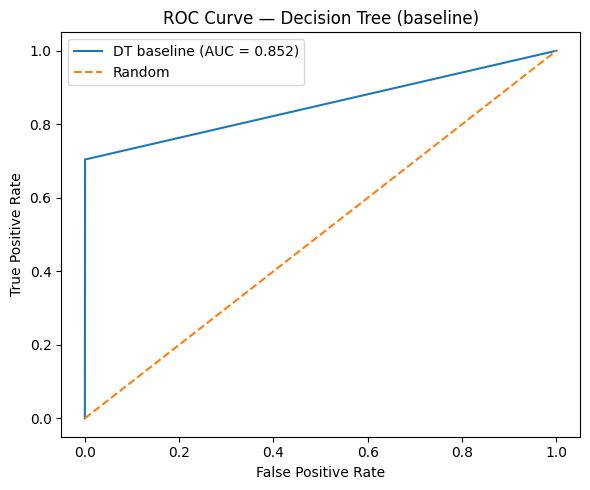

WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/figures/week10/dt_roc_curve_baseline.png')

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"DT baseline (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree (baseline)")
plt.legend()
plt.tight_layout()

roc_path = FIG_DIR / "dt_roc_curve_baseline.png"
plt.savefig(roc_path, dpi=150)
plt.show()
plt.close()

roc_path


## 8. Precision–Recall Curve — DT baseline

Η εικόνα αποθηκεύεται σε:

- `reports/figures/week10/dt_pr_curve_baseline.png`


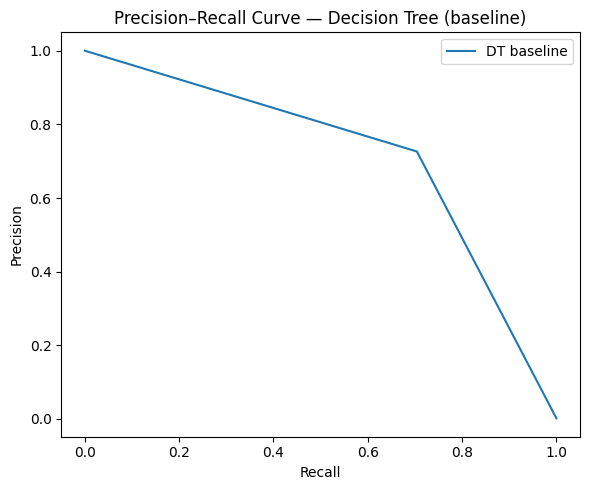

WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/figures/week10/dt_pr_curve_baseline.png')

In [14]:
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(rec_curve, prec_curve, label="DT baseline")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Decision Tree (baseline)")
plt.legend()
plt.tight_layout()

pr_path = FIG_DIR / "dt_pr_curve_baseline.png"
plt.savefig(pr_path, dpi=150)
plt.show()
plt.close()

pr_path


## 9. Confusion Matrix — DT baseline

Η εικόνα αποθηκεύεται σε:

- `reports/figures/week10/dt_baseline_confusion.png`


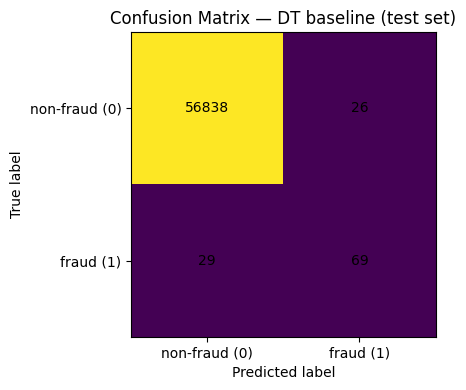

WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/figures/week10/dt_baseline_confusion.png')

In [15]:
import itertools

def plot_confusion_matrix(cm, labels, title, out_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()
    plt.close(fig)


cm_path = FIG_DIR / "dt_baseline_confusion.png"
plot_confusion_matrix(
    cm,
    labels=["non-fraud (0)", "fraud (1)"],
    title="Confusion Matrix — DT baseline (test set)",
    out_path=cm_path,
)

cm_path


## 10. Σύνοψη

- Χρησιμοποιήσαμε το `creditcard_features_week8.csv` σαν modeling base.
- Δημιουργήσαμε stratified splits 60/20/20 και τα αποθηκεύσαμε στο:
  - `data/data_interim/train.csv`
  - `data/data_interim/val.csv`
  - `data/data_interim/test.csv`
- Εκπαιδεύσαμε ένα **baseline Decision Tree**.
- Υπολογίσαμε metrics και τα γράψαμε στο:
  - `reports/week10_decision_tree_vs_logreg/dt_baseline_metrics_notebook.json`
- Παράξαμε plots:
  - `dt_roc_curve_baseline.png`
  - `dt_pr_curve_baseline.png`
  - `dt_baseline_confusion.png`

Επόμενο βήμα:

- tuned Decision Tree (π.χ. `max_depth`, `min_samples_leaf`) χρησιμοποιώντας το **validation set**.
- Σύγκριση με **Logistic Regression baseline** (Week 9) στο report της Εβδομάδας 10.


# Ημέρα 3 — Tuning Decision Tree με GridSearchCV

Στόχος:

- Να βρούμε **καλύτερους hyperparameters** για το Decision Tree,
- χρησιμοποιώντας **GridSearchCV** με κριτήριο το **recall στην κλάση απάτης (Class = 1)**.
- Να αποθηκεύσουμε:
  - αναλυτικά αποτελέσματα του grid search σε CSV,
  - metrics του tuned μοντέλου σε JSON,
  - ROC / PR curves και Confusion Matrix για το tuned μοντέλο σε εικόνες.

Σημείωση: Υποθέτουμε ότι έχουν ήδη οριστεί στο notebook:
- `X_train, y_train, X_val, y_val, X_test, y_test`
- `RAW_DIR`, `FIG_DIR`
- `plot_confusion_matrix` (από το baseline DT).


In [16]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score

# Grid παραμέτρων για δοκιμή
param_grid = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 10, 50],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": [None, "balanced"],
}

base_dt = DecisionTreeClassifier(random_state=42)

# Scorer που μετράει recall στην κλάση απάτης (Class = 1)
recall_scorer = make_scorer(recall_score, pos_label=1)

# Stratified K-Fold για να διατηρείται η αναλογία fraud/non-fraud σε κάθε fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=base_dt,
    param_grid=param_grid,
    scoring=recall_scorer,  # στόχος: μέγιστο recall στην κλάση 1
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)


Fitting 3 folds for each of 90 candidates, totalling 270 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,scoring,"make_scorer(r..., pos_label=1)"
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


## 3.2. Αποτελέσματα GridSearchCV & αποθήκευση σε CSV

- `grid.best_params_`: οι καλύτερες παράμετροι με βάση το **μέσο recall** στα CV folds.
- `grid.best_score_`: το αντίστοιχο **μέσο recall** (Class = 1).
- `grid.cv_results_`: αναλυτικά αποτελέσματα για όλα τα combinations παραμέτρων.

Αποθηκεύουμε τα αποτελέσματα ταξινομημένα κατά `mean_test_score` (descending)
σε CSV:

- `reports/week10_decision_tree_vs_logreg/dt_gridsearch_results.csv`


In [17]:
grid.best_params_, grid.best_score_


({'class_weight': 'balanced',
  'max_depth': 3,
  'min_samples_leaf': 1,
  'min_samples_split': 50},
 np.float64(0.8609565038136466))

In [18]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results_sorted = cv_results.sort_values(by="mean_test_score", ascending=False)

csv_path = RAW_DIR / "dt_gridsearch_results.csv"
cv_results_sorted.to_csv(csv_path, index=False)
csv_path


WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/week10_decision_tree_vs_logreg/dt_gridsearch_results.csv')

## 3.3. Εκπαίδευση tuned Decision Tree & αξιολόγηση στο test set

Χρησιμοποιούμε τα `best_params_` από το GridSearchCV.

Για το τελικό μοντέλο:

- Ενώνουμε **train + val** σε ένα `train_full`:
  - έτσι εκμεταλλευόμαστε όλα τα διαθέσιμα labeled δεδομένα για εκπαίδευση,
  - αφού η επιλογή hyperparameters έχει ήδη γίνει μέσω cross-validation.
- Εκπαιδεύουμε το tuned tree στο `train_full`.
- Αξιολογούμε στο **test set** και αποθηκεύουμε τα metrics σε JSON:

  - `reports/week10_decision_tree_vs_logreg/dt_tuned_metrics.json`

Επίσης θα παράγουμε ROC / PR curves & Confusion Matrix για το tuned μοντέλο.


In [19]:
best_params = grid.best_params_
best_params


{'class_weight': 'balanced',
 'max_depth': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 50}

In [20]:
# Ενοποίηση train + val για τελικό training
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

dt_tuned = DecisionTreeClassifier(
    random_state=42,
    **best_params,
)

dt_tuned.fit(X_train_full, y_train_full)

y_pred_tuned = dt_tuned.predict(X_test)
y_proba_tuned = dt_tuned.predict_proba(X_test)[:, 1]


In [21]:
acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t, rec_t, f1_t, _ = precision_recall_fscore_support(
    y_test, y_pred_tuned, pos_label=1, average="binary"
)
roc_auc_t = roc_auc_score(y_test, y_proba_tuned)
cm_t = confusion_matrix(y_test, y_pred_tuned)

metrics_tuned = {
    "model_type": "decision_tree",
    "variant": "tuned",
    "params": best_params,
    "metrics": {
        "accuracy": acc_t,
        "precision_pos": prec_t,
        "recall_pos": rec_t,
        "f1_pos": f1_t,
        "roc_auc": roc_auc_t,
        "confusion_matrix": cm_t.tolist(),
    },
}

tuned_json = RAW_DIR / "dt_tuned_metrics.json"
with tuned_json.open("w") as f:
    json.dump(metrics_tuned, f, indent=2)

tuned_json


WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/week10_decision_tree_vs_logreg/dt_tuned_metrics.json')

In [22]:
comparison_df = pd.DataFrame(
    {
        "metric": ["accuracy", "precision_pos", "recall_pos", "f1_pos", "roc_auc"],
        "baseline": [acc, prec, rec, f1, roc_auc],   # από το baseline cell
        "tuned":   [acc_t, prec_t, rec_t, f1_t, roc_auc_t],
    }
)
comparison_df


,metric,baseline,tuned
0,accuracy,0.999034,0.955672
1,precision_pos,0.726316,0.033449
2,recall_pos,0.704082,0.887755
3,f1_pos,0.715026,0.064468
4,roc_auc,0.851812,0.945627


## 3.4. ROC / PR curves & Confusion Matrix για το tuned μοντέλο

Αποθηκεύουμε:

- ROC curve: `reports/figures/week10/dt_roc_curve_tuned.png`
- Precision–Recall curve: `reports/figures/week10/dt_pr_curve_tuned.png`
- Confusion Matrix: `reports/figures/week10/dt_tuned_confusion.png`

Έτσι στην Εβδομάδα 10 μπορείς να δείξεις:

- baseline vs tuned DT,
- και να τα συγκρίνεις όλα αυτά με το Logistic Regression baseline (Week 9).


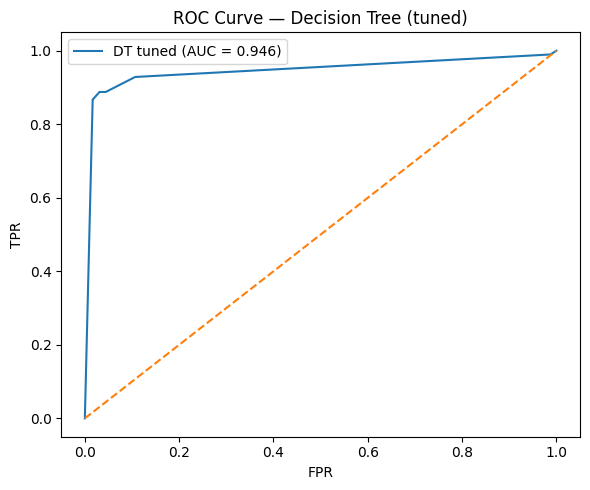

In [26]:
# ROC curve
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_tuned)
plt.figure(figsize=(6, 5))
plt.plot(fpr_t, tpr_t, label=f"DT tuned (AUC = {roc_auc_t:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve — Decision Tree (tuned)")
plt.legend()
plt.tight_layout()

roc_t_path = FIG_DIR / "dt_roc_curve_tuned.png"
plt.savefig(roc_t_path, dpi=150)
plt.show()
plt.close()


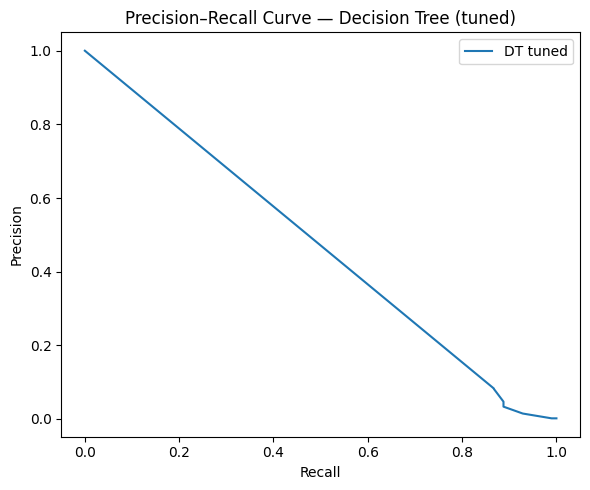

In [27]:
# Precision–Recall curve
prec_curve_t, rec_curve_t, _ = precision_recall_curve(y_test, y_proba_tuned)
plt.figure(figsize=(6, 5))
plt.plot(rec_curve_t, prec_curve_t, label="DT tuned")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Decision Tree (tuned)")
plt.legend()
plt.tight_layout()

pr_t_path = FIG_DIR / "dt_pr_curve_tuned.png"
plt.savefig(pr_t_path, dpi=150)
plt.show()
plt.close()


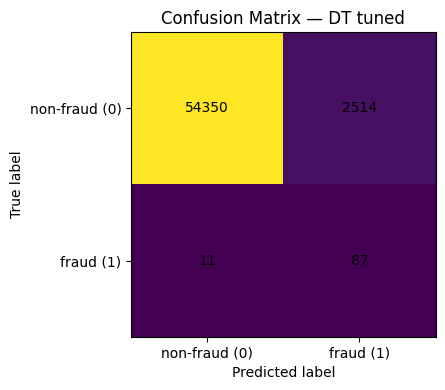

(WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/figures/week10/dt_roc_curve_tuned.png'),
 WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/figures/week10/dt_pr_curve_tuned.png'),
 WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/figures/week10/dt_tuned_confusion.png'))

In [25]:
# Confusion matrix plot για tuned DT
cm_t_path = FIG_DIR / "dt_tuned_confusion.png"
plot_confusion_matrix(
    cm_t,
    labels=["non-fraud (0)", "fraud (1)"],
    title="Confusion Matrix — DT tuned",
    out_path=cm_t_path,
)

roc_t_path, pr_t_path, cm_t_path


# Ημέρα 4 — Visualize Simple Tree (dt_simple_tree.png)

Σκοπός αυτής της ημέρας είναι να φτιάξουμε ένα **ρηχό, απλό Decision Tree** που:

- να χωράει οπτικά σε ένα PNG,
- να μπορεί να διαβαστεί από **managers / business stakeholders**,
- και να μας δώσει 2–3 **ερμηνεύσιμα rules** για την Ενότητα 5 του report.

Χτίζουμε λοιπόν ένα **shallow tree** με:

- `max_depth = 3`  → λίγα επίπεδα, εύκολο διάγραμμα,
- `min_samples_leaf = 50` → αποφεύγουμε leaves με λίγα δείγματα,
- `class_weight = "balanced"` → λαμβάνει υπόψη την ανισορροπία κλάσεων.


In [28]:
from sklearn.tree import DecisionTreeClassifier

dt_shallow = DecisionTreeClassifier(
    random_state=42,
    max_depth=3,
    min_samples_leaf=50,
    class_weight="balanced",
)

dt_shallow.fit(X_train, y_train)

dt_shallow


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


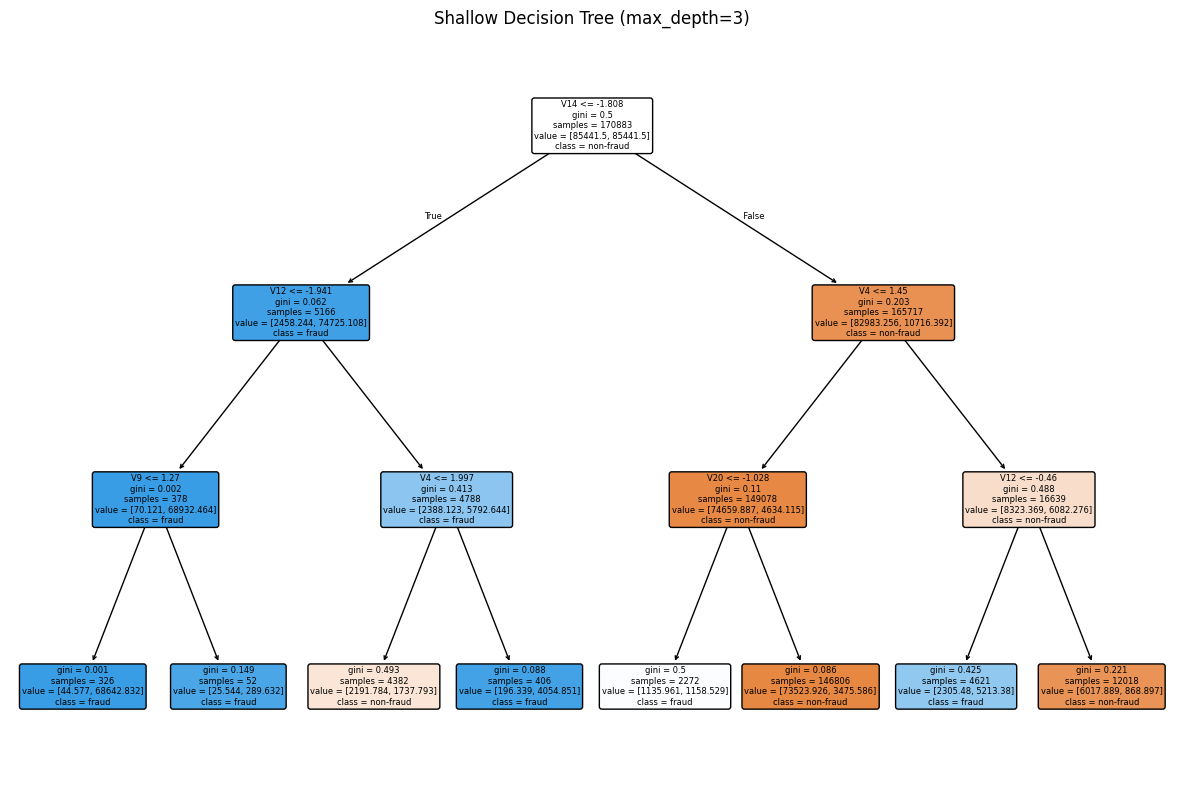

WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/figures/week10/dt_simple_tree.png')

In [30]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(
    dt_shallow,
    feature_names=X_train.columns,
    class_names=["non-fraud", "fraud"],
    filled=True,
    rounded=True,
    fontsize=6,
)
plt.title("Shallow Decision Tree (max_depth=3)")
plt.tight_layout()

simple_tree_path = FIG_DIR / "dt_simple_tree.png"
plt.savefig(simple_tree_path, dpi=200)
plt.show()
plt.close()

simple_tree_path


### 5.x Ενδεικτικά interpretable rules από το shallow Decision Tree

Με βάση το ρηχό δέντρο (max_depth = 3), προκύπτουν ορισμένοι απλοί κανόνες που 
μπορούν να εξηγηθούν σε μη-τεχνικό κοινό. Ενδεικτικά:

1. **Rule 1 — “Ζώνη πολύ υψηλού ρίσκου” σε ακραίες αρνητικές τιμές V14 & V12**

   Το root split γίνεται στο `V14` και αμέσως μετά στο `V12`:

   - Αν `V14 <= -1.808`  
   - **και** ταυτόχρονα `V12 <= -1.941`  

   τότε το δέντρο καταλήγει σχεδόν πάντα σε φύλλα με **κλάση = fraud**  
   (και τα δύο children του επόμενου κόμβου είναι blue / fraud).  
   Αυτό ορίζει μια “ζώνη πολύ αρνητικών τιμών” σε δύο κρυφά components (V14, V12)
   όπου οι συναλλαγές αντιμετωπίζονται από το μοντέλο ως ιδιαίτερα ύποπτες.

2. **Rule 2 — “Ζώνη χαμηλού ρίσκου” όταν V14 δεν είναι πολύ αρνητικό και V20 είναι σχετικά υψηλό**

   Στο δεξί μέρος του δέντρου βλέπουμε έναν πολύ μεγάλο κόμβο non-fraud:

   - Αν `V14 > -1.808`  
   - **και** `V4 <= 1.45`  
   - **και** `V20 > -1.028`  

   τότε η συναλλαγή οδηγείται σε μεγάλο φύλλο με χρώμα πορτοκαλί και  
   **κλάση = non-fraud** (πολύ μεγάλη πλειοψηφία κανονικών συναλλαγών).  
   Αυτή είναι ουσιαστικά η “ασφαλής περιοχή” όπου το σύστημα θεωρεί ότι οι συναλλαγές
   είναι σχεδόν πάντα νόμιμες.

3. **Rule 3 — “Δεξιά ζώνη κινδύνου” όταν V4 είναι υψηλό και V12 αρκετά αρνητικό**

   Στη δεξιά πλευρά, ένα άλλο branch επιστρέφει συχνά fraud:

   - Αν `V14 > -1.808`  
   - **και** `V4 > 1.45`  
   - **και** `V12 <= -0.46`  

   τότε το δέντρο φτάνει σε φύλλο με **κλάση = fraud**.  
   Αυτό σημαίνει ότι, ακόμη κι όταν δεν είμαστε στην “πολύ ακραία” περιοχή του V14,
   ένας συγκεκριμένος συνδυασμός **υψηλού V4** και **αρκετά αρνητικού V12**
   “ανάβει κόκκινο” και χαρακτηρίζει τη συναλλαγή ως ύποπτη.

Οι κανόνες αυτοί **δεν είναι απόλυτοι** (το Decision Tree λειτουργεί σε επίπεδο πιθανοτήτων 
και κάθε φύλλο περιέχει μίξη fraud / non-fraud), αλλά δίνουν μια **διαφανή, 
ερμηνεύσιμη εικόνα** του πώς το μοντέλο ορίζει “ζώνες κινδύνου” και “ζώνες ασφάλειας”
στον χώρο των χαρακτηριστικών V14, V12, V20 και V4.


# Ημέρα 5 — Σύγκριση με Logistic Regression + Threshold Analysis

Στόχος:

1. Να συγκρίνουμε **Logistic Regression baseline (Week 9)** με το **tuned Decision Tree (Week 10)** 
   σε βασικά business metrics:
   - Precision στην κλάση απάτης (Class = 1)
   - Recall στην κλάση απάτης
   - F1 για την κλάση απάτης
   - ROC AUC
2. Να αποθηκεύσουμε τα αποτελέσματα σε:
   - `model_comparison.csv`
   - `logreg_vs_dt_metrics.png`
3. Να κάνουμε **threshold analysis** στο tuned Decision Tree:
   - διαφορετικά thresholds (0.3, 0.5, 0.7),
   - trade-off Precision vs Recall,
   - αποθήκευση σε `dt_threshold_scenarios.csv`
   για χρήση στην Ενότητα 7 του report.


## 5.1. Φόρτωση metrics JSON & δημιουργία model_comparison.csv

Χρησιμοποιούμε τα JSON files που έχουν αποθηκευτεί από τις προηγούμενες εβδομάδες:

- Logistic Regression baseline (Week 9):  
  `reports/week9_baseline/metrics.json`
- Tuned Decision Tree (Week 10):  
  `reports/week10_decision_tree_vs_logreg/dt_tuned_metrics.json`

Φτιάχνουμε έναν μικρό πίνακα σύγκρισης και τον αποθηκεύουμε ως:

- `reports/week10_decision_tree_vs_logreg/model_comparison.csv`


In [41]:
# Paths για τα JSON metrics
logreg_json_path = PROJECT_ROOT / "reports" / "week9_baseline" / "metrics.json"
dt_json_path = RAW_DIR / "dt_tuned_metrics.json"

with logreg_json_path.open() as f:
    logreg_raw = json.load(f)

with dt_json_path.open() as f:
    dt_raw = json.load(f)

# Week 9: metrics στο top-level
logreg_metrics = logreg_raw

# Week 10: metrics μέσα στο "metrics"
dt_metrics = dt_raw["metrics"] if "metrics" in dt_raw else dt_raw

rows = []

# ------------- Logistic Regression baseline -------------
rows.append(
    {
        "Model": "LogisticRegression",
        # δεν έχεις accuracy στο JSON, το αφήνουμε None/NaN
        "Accuracy": logreg_metrics.get("accuracy", None),
        "Precision_fraud": logreg_metrics["precision"],
        "Recall_fraud": logreg_metrics["recall"],
        "F1_fraud": logreg_metrics["f1"],
        "ROC_AUC": logreg_metrics["roc_auc"],
    }
)

# ------------- Decision Tree tuned -------------
rows.append(
    {
        "Model": "DecisionTree_tuned",
        "Accuracy": dt_metrics["accuracy"],
        "Precision_fraud": dt_metrics["precision_pos"],
        "Recall_fraud": dt_metrics["recall_pos"],
        "F1_fraud": dt_metrics["f1_pos"],
        "ROC_AUC": dt_metrics["roc_auc"],
    }
)

df_comp = pd.DataFrame(rows)
comp_path = RAW_DIR / "model_comparison.csv"
df_comp.to_csv(comp_path, index=False)

comp_path, df_comp


(WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/week10_decision_tree_vs_logreg/model_comparison.csv'),
                 Model  Accuracy  Precision_fraud  Recall_fraud  F1_fraud  \
 0  LogisticRegression       NaN         0.060976      0.918367  0.114358   
 1  DecisionTree_tuned  0.955672         0.033449      0.887755  0.064468   
 
     ROC_AUC  
 0  0.972083  
 1  0.945627  )

## 5.2. Οπτική σύγκριση LogReg vs Decision Tree (tuned)

Για πιο “manager-friendly” παρουσίαση, φτιάχνουμε ένα bar chart με:

- x-axis: τα metrics (`Precision_fraud`, `Recall_fraud`, `F1_fraud`, `ROC_AUC`)
- 2 bars ανά metric:
  - Logistic Regression
  - Decision Tree (tuned)

Η εικόνα αποθηκεύεται στο:

- `reports/figures/week10/logreg_vs_dt_metrics.png`


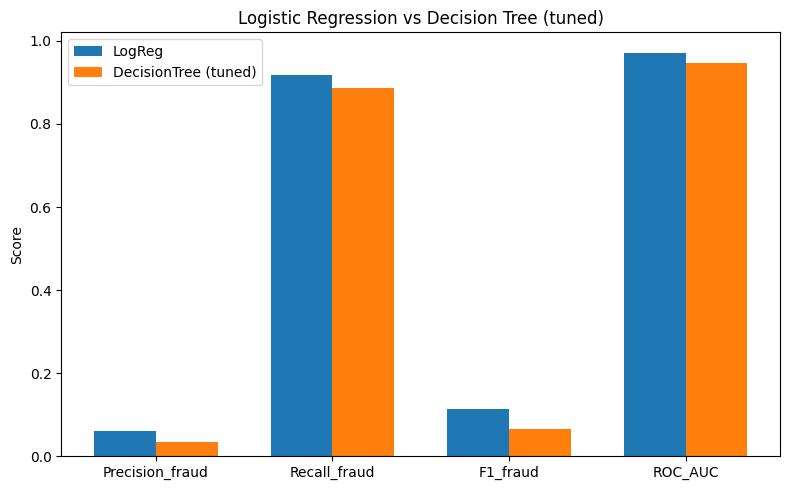

WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/figures/week10/logreg_vs_dt_metrics.png')

In [40]:
metrics_to_plot = ["Precision_fraud", "Recall_fraud", "F1_fraud", "ROC_AUC"]

x = np.arange(len(metrics_to_plot))
width = 0.35

logreg_values = df_comp[df_comp["Model"] == "LogisticRegression"][metrics_to_plot].values[0]
dt_values = df_comp[df_comp["Model"] == "DecisionTree_tuned"][metrics_to_plot].values[0]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, logreg_values, width, label="LogReg")
plt.bar(x + width/2, dt_values, width, label="DecisionTree (tuned)")

plt.xticks(x, metrics_to_plot)
plt.ylabel("Score")
plt.title("Logistic Regression vs Decision Tree (tuned)")
plt.legend()
plt.tight_layout()

plot_path = FIG_DIR / "logreg_vs_dt_metrics.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path, dpi=150)
plt.show()
plt.close()

plot_path


## 5.3. Threshold analysis για το tuned Decision Tree

Μέχρι τώρα θεωρούσαμε default threshold **0.5**:  
αν `P(fraud) >= 0.5` → προβλέπουμε fraud.

Για business λόγους όμως μπορεί να θέλουμε:

- **χαμηλότερο threshold** για να “πιάνουμε” περισσότερες απάτες (υψηλότερο recall) 
  με κόστος περισσότερα false positives,
- ή **υψηλότερο threshold** για να περιορίσουμε false positives με κόστος χαμηλότερου recall.

Εξετάζουμε τρία thresholds:

- 0.3 (επιθετικό — κυνηγάμε recall)
- 0.5 (standard)
- 0.7 (συντηρητικό — κυνηγάμε precision)

Υπολογίζουμε:

- precision_fraud
- recall_fraud
- f1_fraud

και τα αποθηκεύουμε σε:

- `reports/week10_decision_tree_vs_logreg/dt_threshold_scenarios.csv`


In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.5, 0.7]
rows = []

for thr in thresholds:
    y_pred_thr = (y_proba_tuned >= thr).astype(int)

    prec_thr = precision_score(y_test, y_pred_thr, pos_label=1)
    rec_thr = recall_score(y_test, y_pred_thr, pos_label=1)
    f1_thr = f1_score(y_test, y_pred_thr, pos_label=1)

    rows.append(
        {
            "threshold": thr,
            "precision_fraud": prec_thr,
            "recall_fraud": rec_thr,
            "f1_fraud": f1_thr,
        }
    )

df_thr = pd.DataFrame(rows)

thr_path = RAW_DIR / "dt_threshold_scenarios.csv"
df_thr.to_csv(thr_path, index=False)

thr_path, df_thr


(WindowsPath('C:/Users/ΛΑΖΑΡΟΣ/Documents/Projects/cc-fraud-detection/reports/week10_decision_tree_vs_logreg/dt_threshold_scenarios.csv'),
    threshold  precision_fraud  recall_fraud  f1_fraud
 0        0.3         0.033449      0.887755  0.064468
 1        0.5         0.033449      0.887755  0.064468
 2        0.7         0.046976      0.887755  0.089231)